In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Load Datasets

In [2]:
movie_theater_id_relation = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
cinepos_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cinepos_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# Import Libraries

In [3]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score 

In [4]:
booknow_visits.describe()

,audience_count
count,214046.000000
mean,41.616568
std,32.834918
min,2.000000
25%,18.000000
50%,34.000000
75%,58.000000
max,1350.000000


# Visualizations

/tmp/ipykernel_13/730544158.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['show_date'] = pd.to_datetime(df_filtered['show_date'])


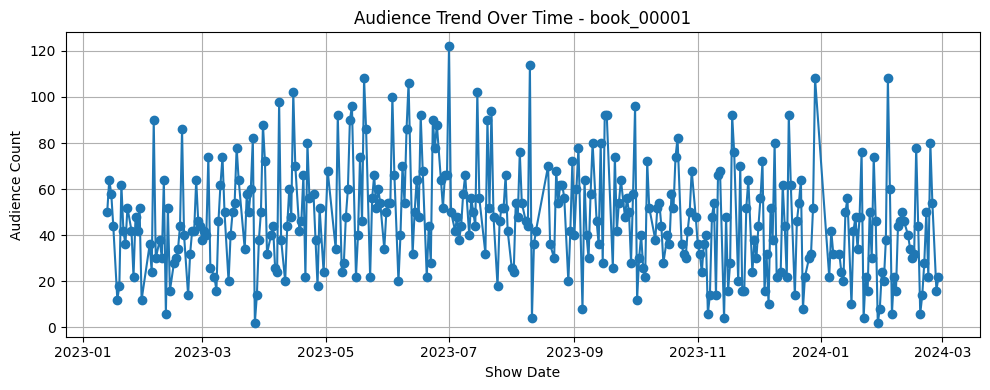

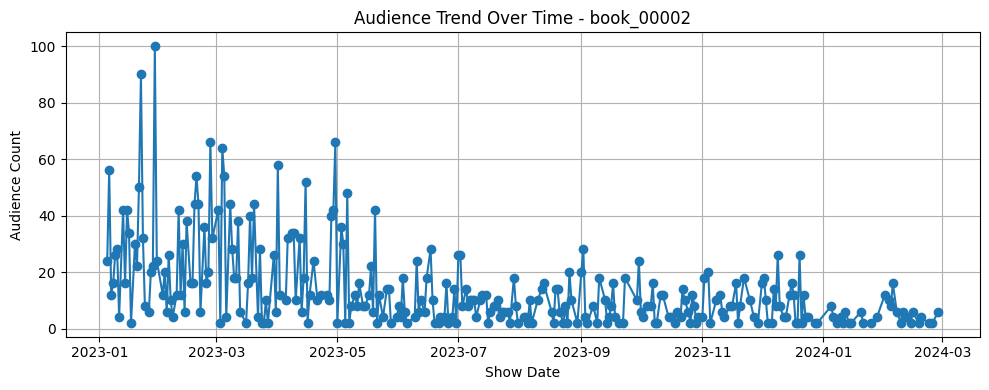

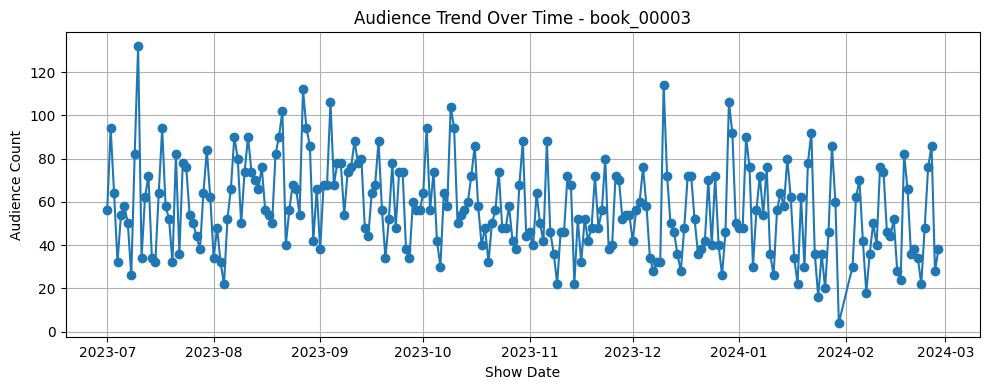

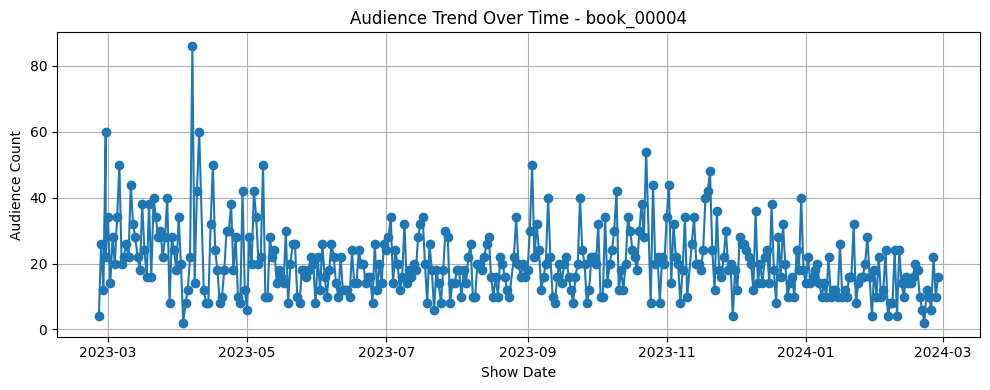

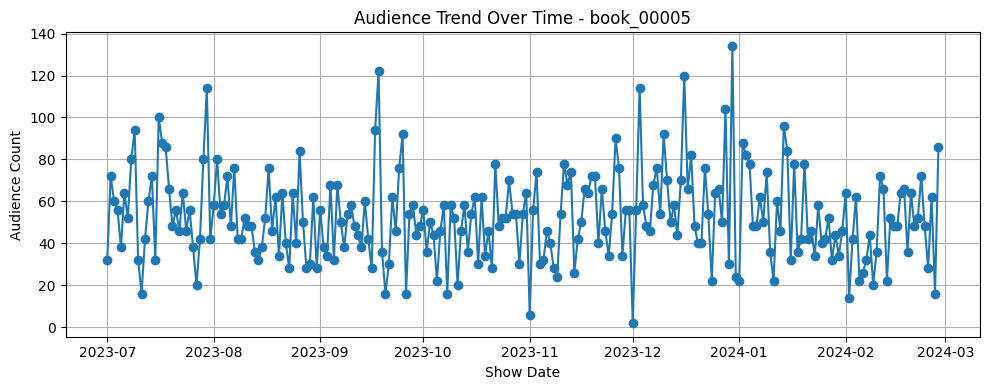

In [5]:
#Line chart
import matplotlib.pyplot as plt

theater_ids = ['book_00001', 'book_00002', 'book_00003', 'book_00004', 'book_00005']

df_filtered = booknow_visits[booknow_visits['book_theater_id'].isin(theater_ids)]
df_filtered['show_date'] = pd.to_datetime(df_filtered['show_date'])

# One chart per theatre ID
for t_id in theater_ids:
    temp = df_filtered[df_filtered['book_theater_id'] == t_id]

    plt.figure(figsize=(10, 4))
    plt.plot(temp['show_date'], temp['audience_count'], marker='o')
    
    plt.title(f"Audience Trend Over Time - {t_id}")
    plt.xlabel("Show Date")
    plt.ylabel("Audience Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


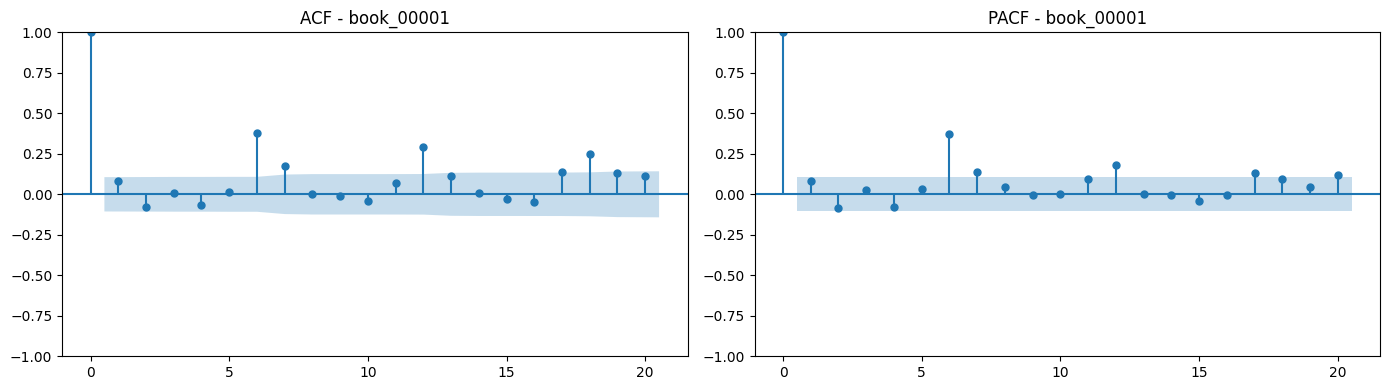

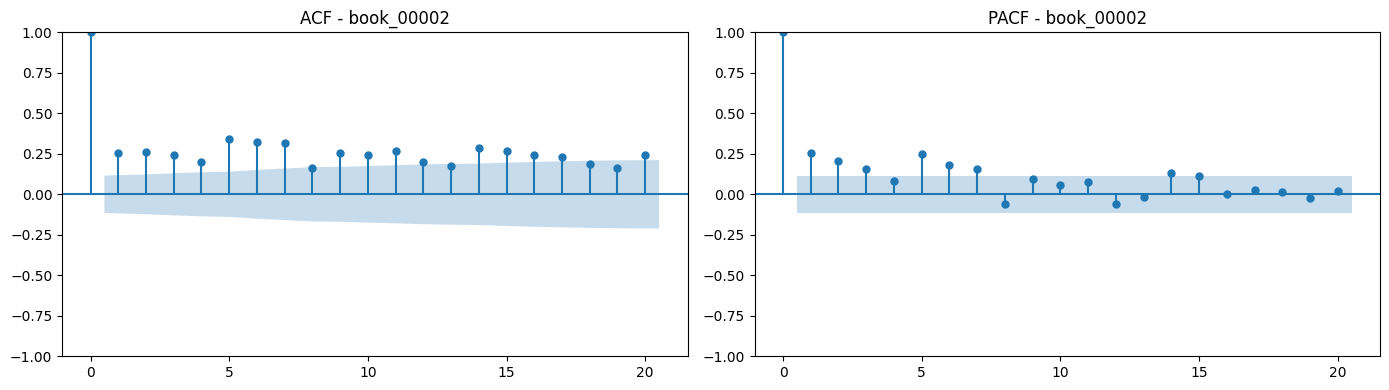

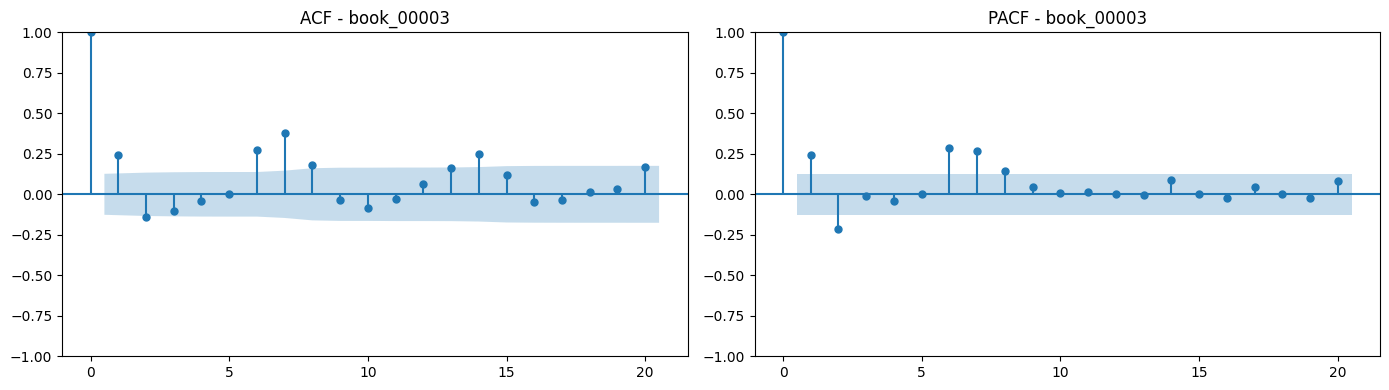

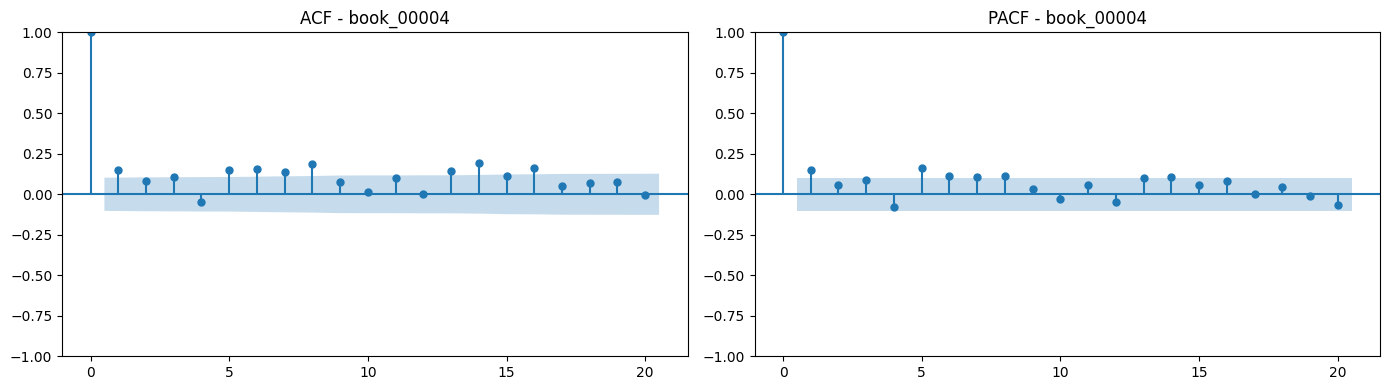

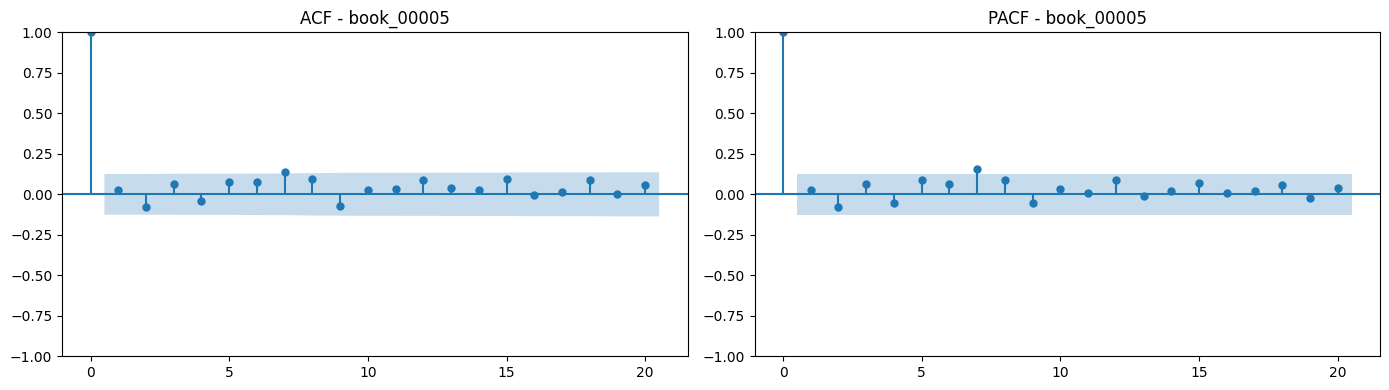

In [6]:
# ACF(AutoCorrelation Function), PACF(Partial AutoCorrelation Function)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

theater_ids = ['book_00001', 'book_00002', 'book_00003', 'book_00004', 'book_00005']

df_filtered = booknow_visits[booknow_visits['book_theater_id'].isin(theater_ids)].copy()
df_filtered['show_date'] = pd.to_datetime(df_filtered['show_date'])

# sort by date
df_filtered = df_filtered.sort_values('show_date')

# loop for each theatre
for t_id in theater_ids:
    temp = df_filtered[df_filtered['book_theater_id'] == t_id]

    # create time series
    ts = temp.set_index('show_date')['audience_count']

    # create figure 
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ACF
    plot_acf(ts, lags=20, ax=axes[0])
    axes[0].set_title(f"ACF - {t_id}")

    # PACF
    plot_pacf(ts, lags=20, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF - {t_id}")

    plt.tight_layout()
    plt.show()


In [7]:
# Coverting show_date column datatype from string to datetime 
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'], errors='coerce')
sample_submission['show_date'] = sample_submission['ID'].str.rsplit('_', n=1, expand=True)[1]
sample_submission['show_date'] = pd.to_datetime(sample_submission['show_date'], errors='coerce')

# build test frame (book_theater_id, show_date)
test = sample_submission['ID'].str.rsplit('_', n=1, expand=True)
test.columns = ['book_theater_id', 'show_date']
test['book_theater_id'] = test['book_theater_id'].astype(str)
test['show_date'] = pd.to_datetime(test['show_date'], errors='coerce')

# Merge BookNow & CinePOS Datasets

In [8]:
bn = booknow_booking.copy()
bn['show_datetime'] = pd.to_datetime(bn['show_datetime'], errors='coerce')

# Extract date
bn['show_date'] = bn['show_datetime'].dt.date
bn['show_date'] = pd.to_datetime(bn['show_date'])

bn['book_theater_id'] = bn['book_theater_id'].astype(str)

# Sum tickets booked per theatre per date
bn_agg = (
    bn.groupby(['book_theater_id','show_date'])['tickets_booked']
      .sum()
      .reset_index()
      .rename(columns={'tickets_booked':'booking_bn'})
)

# Cinepos booking counts
cp = cinepos_booking.copy()
cp['show_datetime'] = pd.to_datetime(cp['show_datetime'], errors='coerce')

cp['show_date'] = cp['show_datetime'].dt.date
cp['show_date'] = pd.to_datetime(cp['show_date'])

cp['cine_theater_id'] = cp['cine_theater_id'].astype(str)

# Map CinePOS → BookNow theater ID
rel = movie_theater_id_relation.copy()
rel['book_theater_id'] = rel['book_theater_id'].astype(str)
rel['cine_theater_id'] = rel['cine_theater_id'].astype(str)

cp_mapped = cp.merge(rel, on='cine_theater_id', how='left')

# Sum tickets sold per date per book theater
cp_agg = (
    cp_mapped.groupby(['book_theater_id','show_date'])['tickets_sold']
      .sum()
      .reset_index()
      .rename(columns={'tickets_sold':'booking_cp'})
)

# Feature Engineering Function (Calender)

In [9]:
def add_calendar_feats(df):
    df = df.copy()
    d = df['show_date']
    
    df['year'] = d.dt.year
    df['month'] = d.dt.month               
    df['is_weekend'] = (d.dt.weekday >= 5).astype(int)  
    
    # cyclic encodings
    df['month_sin'] = np.sin(2 * np.pi * d.dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * d.dt.month / 12)
    df['day_sin'] = np.sin(2 * np.pi * d.dt.day / 31)
    df['day_cos'] = np.cos(2 * np.pi * d.dt.day / 31)
    df['weekday_sin'] = np.sin(2 * np.pi * d.dt.weekday / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * d.dt.weekday / 7)
    
    return df

# Feature Engineering (Lag and Rolling Features)


In [10]:
train_feat = add_calendar_feats(booknow_visits[['book_theater_id','show_date','audience_count']])
train_feat = train_feat.sort_values(['book_theater_id', 'show_date'])

# Adding lags
for lag in [1,2,3,7,14]:
 train_feat[f'lag_{lag}'] = (
        train_feat.groupby('book_theater_id')['audience_count']
                  .shift(lag)
    )

# Rolling windows
for window in [7, 14]:
    train_feat[f'rolling_mean_{window}'] = (
        train_feat.groupby('book_theater_id')['audience_count']
                  .shift(1)  # exclude today
                  .rolling(window=window)
                  .mean()
    )
    train_feat[f'rolling_std_{window}'] = (
        train_feat.groupby('book_theater_id')['audience_count']
                  .shift(1)
                  .rolling(window=window)
                  .std()
    )


# Drop missing rows due to lags
train_feat = train_feat.dropna()

# Prepare last known audience_count for each theater
last_values = (
    train_feat.sort_values(['book_theater_id', 'show_date'])
             .groupby('book_theater_id')['audience_count']
             .last()
             .to_dict()
)

test_feat  = add_calendar_feats(test[['book_theater_id','show_date']])
test_sorted = test_feat.sort_values(['book_theater_id', 'show_date']).copy()

lag_list = [1,2,3,7,14]
rolling_list = [7,14]

for lag in lag_list:
    test_sorted[f'lag_{lag}'] = np.nan

for window in rolling_list:
    test_sorted[f'rolling_mean_{window}'] = np.nan
    test_sorted[f'rolling_std_{window}'] = np.nan


# Merging External Booking Data into Training and Testing Features

In [11]:
# Merge BookNow bookings
train_feat = train_feat.merge(bn_agg, on=['book_theater_id','show_date'], how='left')
test_feat  = test_feat.merge(bn_agg, on=['book_theater_id','show_date'], how='left')

# Merge CinePOS bookings
train_feat = train_feat.merge(cp_agg, on=['book_theater_id','show_date'], how='left')
test_feat  = test_feat.merge(cp_agg, on=['book_theater_id','show_date'], how='left')

# Fill missing with 0
train_feat['booking_bn'] = train_feat['booking_bn'].fillna(0)
train_feat['booking_cp'] = train_feat['booking_cp'].fillna(0)
test_feat['booking_bn']  = test_feat['booking_bn'].fillna(0)
test_feat['booking_cp']  = test_feat['booking_cp'].fillna(0)


# Booking-based interactions
train_feat['total_booking'] = train_feat['booking_bn'] + train_feat['booking_cp']
train_feat['online_offline_ratio'] = (
    train_feat['booking_bn'] / (train_feat['booking_cp'] + 1)
)

# Model Building and Hyperparameter Tuning

In [12]:
# Define X and y 
X = train_feat.drop(columns=['audience_count'])
y = train_feat['audience_count'].values

num_cols = [
    'year','month_sin','month_cos','day_sin','day_cos','is_weekend','weekday_sin','weekday_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14','rolling_mean_7', 'rolling_mean_14','rolling_std_7', 'rolling_std_14',
    'booking_bn', 'booking_cp', 'total_booking', 'online_offline_ratio'
]

scale_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_mean_14',
    'rolling_std_7', 'rolling_std_14',
    'booking_bn', 'booking_cp', 'total_booking', 'online_offline_ratio'
]

passthrough_cols = [
    'year', 'month_sin', 'month_cos',
    'day_sin', 'day_cos',
    'is_weekend',
    'weekday_sin', 'weekday_cos'
]

# ColumnTransformer
ct = ColumnTransformer([
    ('id', OneHotEncoder(handle_unknown='ignore'), ['book_theater_id']), 
    ('scale', StandardScaler(), scale_cols),
    ('num', 'passthrough', passthrough_cols),               
])

tscv = TimeSeriesSplit(n_splits=3)

models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(random_state=42, solver="lsqr"),

    "Lasso": Lasso(random_state=42),

    "XGBoost": XGBRegressor(tree_method="hist",       
        eval_metric="rmse",
        random_state=42),

    "LightGBM": LGBMRegressor(boosting_type="gbdt",
        n_jobs=-1, verbosity=-1, random_state=42),
}

param_grids = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1, 10]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
    }
}

best_estimators = {}
best_scores = {}

for name, model in models.items():

    #print(f"\n----- TUNING: {name} -----")

    pipe = Pipeline([
        ('features', ct),
        ('model', model),
    ])

    # If model is not in param gride, valuate normally
    if name not in param_grids:
        scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')
        best_estimators[name] = pipe
        best_scores[name] = scores.mean()
        print(f"{name}: Mean CV R² = {scores.mean():.4f}")
        continue

    # Hyperparameter tuning
    grid = RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[name],
        cv=tscv,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    grid.fit(X, y)

    best_estimators[name] = grid.best_estimator_.named_steps.model
    best_scores[name] = grid.best_score_

    print(f"BEST PARAMS ({name}):", grid.best_params_)
    print(f"BEST CV R² ({name}):", grid.best_score_)

best_model_name = max(best_scores, key=best_scores.get)
final_model = best_estimators[best_model_name]

print("\n Best Model:", best_model_name)
print("Best CV Score:", best_scores[best_model_name])


LinearRegression: Mean CV R² = 0.3768
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


BEST PARAMS (Ridge): {'model__alpha': 10}
BEST CV R² (Ridge): 0.4237555705893324
Lasso: Mean CV R² = 0.4894
Fitting 3 folds for each of 10 candidates, totalling 30 fits
BEST PARAMS (XGBoost): {'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05}
BEST CV R² (XGBoost): 0.5239716619373624
LightGBM: Mean CV R² = 0.5235

 Best Model: XGBoost
Best CV Score: 0.5239716619373624


In [13]:

final_pipe = Pipeline([
    ('features', ct),
    ('model', final_model),
])

final_pipe.fit(X, y)


Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('id',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['book_theater_id']),
                                                 ('scale', StandardScaler(),
                                                  ['lag_1', 'lag_2', 'lag_3',
                                                   'lag_7', 'lag_14',
                                                   'rolling_mean_7',
                                                   'rolling_mean_14',
                                                   'rolling_std_7',
                                                   'rolling_std_14',
                                                   'booking_bn', 'booking_cp',
                                                   'total_booking',
                                                   'online_offline_ratio']),
                                                 ('num', 'passthrough',...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [14]:
# PREDICT & BUILD SUBMISSION 
predictions = []

for theater_id, group in test_sorted.groupby('book_theater_id'):

    # Historical audience counts for this theater
    history = list(train_feat[train_feat['book_theater_id'] == theater_id]['audience_count'])
    history = history[-30:] if len(history) > 0 else [0]

    for idx, row in group.iterrows():
        row_features = row.copy()

        # ---- LAG FEATURES ----
        for lag in [1, 2, 3, 7, 14]:
            row_features[f'lag_{lag}'] = history[-lag] if len(history) >= lag else history[-1]

        # ---- ROLLING FEATURES ----
        for window in [7, 14]:
            row_features[f'rolling_mean_{window}'] = np.mean(history[-window:]) if len(history) >= window else np.mean(history)
            row_features[f'rolling_std_{window}'] = np.std(history[-window:]) if len(history) >= window else np.std(history)

        # ---- BOOKING FEATURES ----
        row_features['booking_bn'] = row_features.get('booking_bn', 0)
        row_features['booking_cp'] = row_features.get('booking_cp', 0)
        row_features['total_booking'] = row_features['booking_bn'] + row_features['booking_cp']
        row_features['online_offline_ratio'] = row_features['booking_bn'] / (row_features['booking_cp'] + 1)

        # ---- BUILD INPUT ROW ----
        X_row = row_features[['book_theater_id', 'month'] + num_cols]

        # ---- PREDICT ----
        y_pred = final_pipe.predict(pd.DataFrame([X_row]))[0]

        # ---- STORE & UPDATE ----
        predictions.append((row['book_theater_id'], row['show_date'], y_pred))
        history.append(y_pred)


# Submission

In [15]:
pred_df = pd.DataFrame(predictions, columns=['book_theater_id','show_date','audience_count'])

# final merge 
final_df = test.merge(pred_df, on=['book_theater_id','show_date'], how='left')

# fix NaN
final_df['audience_count'] = (
    final_df['audience_count']
    .fillna(0)
    .clip(lower=0)
    .round()
    .astype(int)
)

submission = pd.DataFrame({
    'ID': sample_submission['ID'],
    'target': final_df['audience_count']
})

submission.to_csv("submission.csv", index=False)
print("submission.csv generated successfully!")

submission.csv generated successfully!
